In [1]:
import sys
#!{sys.executable} -m pip install spacy


In [2]:
import nltk
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from pathlib import Path
from tqdm import tqdm
import contractions
from nltk import pos_tag
from nltk.corpus import stopwords
import ast
import matplotlib.ticker as ticker

c:\Users\alvar\AppData\Local\Programs\Python\Python311\Lib\site-packages\nltk\metrics\association.py:26: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy.stats import fisher_exact


In [4]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
# Initialize stemmer/lemmatizer (run once)
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [5]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\alvar\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [6]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

In [7]:
def get_vader_scores(sent_list, sentiment):
    if not isinstance(sent_list, list):
        return []
    return [sia.polarity_scores(sentence)[sentiment] for sentence in sent_list if isinstance(sentence, str)]

In [8]:
def clean_and_lowercase_list_column(df, column_name):
    """
    Converts stringified lists in a column to real lists and lowercases each string element.
    
    Parameters:
        df (pd.DataFrame): The DataFrame containing the column.
        column_name (str): The name of the column to clean.
    
    Returns:
        pd.DataFrame: A copy of the DataFrame with the cleaned column.
    """
    # df = df.copy()
    
    # Convert stringified lists to real lists
    df[column_name] = df[column_name].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else x
    )
    
    # Lowercase each string in the list
    df[column_name] = df[column_name].apply(
        lambda lst: [s.lower() for s in lst] if isinstance(lst, list) else lst
    )
    
    return df


In [9]:
from scipy.stats import sem, t
import numpy as np

def compute_ci(series, confidence=0.95):
    series = series.dropna()
    n = len(series)
    if n < 2:
        return (np.nan, np.nan, np.nan)
    m = series.mean()
    se = sem(series)
    h = se * t.ppf((1 + confidence) / 2., n - 1)
    return (m, m - h, m + h)


In [10]:
def get_ci_and_average(df, column_name, sentiments=['neg', 'neu', 'pos', 'compound']):

    full_df = df.copy()

    results = {}  # store each income level's dataframe

    for i in range(1, 5):
        print(i)
        final_df = pd.DataFrame()
        print(f" ------------------------------Income {i} ------------------------------")
        df_i = full_df[full_df['Income Level'] == i].copy()

        print(len(df_i))
        for j in sentiments:
            df_i[f'vader_col_{j}'] = df_i[column_name].apply(get_vader_scores, sentiment = j)
            # Aggregate sentiment statistics
            df_i[f'vader_avg_{j}'] = df_i[f'vader_col_{j}'].apply(lambda scores: sum(scores)/len(scores) if scores else None)

            country_year_avg = df_i.groupby(['Year', 'ISO-Code'])[f'vader_avg_{j}'].mean().reset_index()

            if j == sentiments[0]:
                country_counts = country_year_avg.groupby('Year')['ISO-Code'].nunique().rename(f'n_countries_{i}')
                final_df = pd.DataFrame(country_counts)

            # country_counts = country_year_avg.groupby('Year')['ISO-Code'].nunique()
            # Compute mean + 95% CI for each year
            ci_df = country_year_avg.groupby('Year')[f'vader_avg_{j}'].apply(compute_ci).apply(pd.Series)
            ci_df.columns = [f'mean_{j}_{i}', f'lower_{j}_{i}', f'upper_{j}_{i}']

            # Join to final_df
            if final_df.empty:
                final_df = ci_df.copy()
            else:
                final_df = final_df.join(ci_df, how='outer')  # join on Year index

        results[i] = final_df.reset_index()  # store result for each income level

    return results

# Step 2: Load the speeches

In [11]:
base_path_alvaro = Path(r"C:\Users\alvar\OneDrive\Escritorio\BDS\Block_5\NLP\Project")

base_path = base_path_alvaro # change according to user

In [12]:
final_df = pd.read_csv(base_path / "Final_df.csv")
df_sentiment = final_df[final_df['contains_climate_keyword'] != False]
df_sentiment

,Session,Year,ISO-Code,Speech,number_sentences,number_tokens,Income Level,cleaned_speeches_postagging_expanded,speeches_for_keyword_search,matched_climate_keywords,contains_climate_keyword
5,45,1990,ATG,"﻿Please accept my country's congratulations, S...",115,3134,3,please accept country congratulation sir unani...,please accept my country's congratulations sir...,['global warming'],True
6,45,1990,AUS,"﻿It is with great pleasure. Sir, that I congra...",162,5289,4,great pleasure sir congratulate election presi...,it is with great pleasure. sir that i congratu...,['global environment'],True
7,45,1990,AUT,"﻿\n\nI am pleased, Sir, to congratulate you on...",162,4743,4,pleased sir congratulate election presidency g...,i am pleased sir to congratulate you on your e...,"['carbon dioxide', 'emissions', 'global enviro...",True
11,45,1990,BFA,"﻿\nMr. President, events in Eastern and Centra...",91,2948,1,president event eastern central europe gratify...,mr. president events in eastern and central eu...,"['carbon dioxide', 'greenhouse effect', 'ozone...",True
12,45,1990,BGD,"﻿\nMr. President, warm felicitations are due y...",180,3107,1,president warm felicitation due welldeserved e...,mr. president warm felicitations are due you o...,['climate change'],True
...,...,...,...,...,...,...,...,...,...,...,...
6452,79,2024,WSM,"Excellencies, \nI extend my congratulations t...",68,1572,2,excellency extend congratulation excellency ph...,excellencies i extend my congratulations to hi...,"['climate change', 'climate action', 'temperat...",True
6453,79,2024,YEM,"Your Majesties, Excellencies, and Highnesses, ...",57,1876,1,lady gentleman happy coincidence address today...,ladies and gentlemen it is a happy coincidence...,['climate change'],True
6454,79,2024,ZAF,President of the 79th Session of the UN Genera...,100,1870,3,president session general assembly philemon ya...,president of the 79th session of the un genera...,"['climate change', 'climate action', 'emission...",True
6455,79,2024,ZMB,"\n YOUR EXCELLENCY PHILEMON YANG, PRESIDENT O...",81,2348,2,lady gentleman congratulate excellency assumpt...,ladies and gentlemen i congratulate you your e...,"['climate change', 'extreme weather', 'climate...",True


In [13]:
type(df_sentiment.iloc[0]['matched_climate_keywords'])

str

## IMPORTANT STEP TURN EACH COLUMN 

In [14]:
df_sentiment = clean_and_lowercase_list_column(df_sentiment, 'matched_climate_keywords')
type(df_sentiment.iloc[0]['matched_climate_keywords'])

C:\Users\alvar\AppData\Local\Temp\ipykernel_2316\1447317861.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(
C:\Users\alvar\AppData\Local\Temp\ipykernel_2316\1447317861.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(


list

# Step 3: Add sentences with the keywords as a column

In [16]:
import spacy

nlp = spacy.load("en_core_web_sm")

tqdm.pandas()

def extract_climate_sentences(speech, keywords):
    """
    Filters the sentences in a speech that contain any of the specified climate-related keywords.
    Args:
        speech (str): The speech text to analyze.
        keywords (list of str): A list of climate-related keywords to search for.
    """
    doc = nlp(speech)
    keyword_sentences = []
    for sent in doc.sents:
        matches = [kw for kw in keywords if kw.lower() in sent.text.lower()]
        if matches:
            keyword_sentences.append(sent.text.strip())
    return keyword_sentences

#df_sentiment['climate_sentences'] = df_sentiment.progress_apply(
#    lambda row: extract_climate_sentences(row['speeches_for_keyword_search'], row['matched_climate_keywords']),
#    axis=1
#)

df_sentiment

,Session,Year,ISO-Code,Speech,number_sentences,number_tokens,Income Level,cleaned_speeches_postagging_expanded,speeches_for_keyword_search,matched_climate_keywords,contains_climate_keyword
5,45,1990,ATG,"﻿Please accept my country's congratulations, S...",115,3134,3,please accept country congratulation sir unani...,please accept my country's congratulations sir...,[global warming],True
6,45,1990,AUS,"﻿It is with great pleasure. Sir, that I congra...",162,5289,4,great pleasure sir congratulate election presi...,it is with great pleasure. sir that i congratu...,[global environment],True
7,45,1990,AUT,"﻿\n\nI am pleased, Sir, to congratulate you on...",162,4743,4,pleased sir congratulate election presidency g...,i am pleased sir to congratulate you on your e...,"[carbon dioxide, emissions, global environmental]",True
11,45,1990,BFA,"﻿\nMr. President, events in Eastern and Centra...",91,2948,1,president event eastern central europe gratify...,mr. president events in eastern and central eu...,"[carbon dioxide, greenhouse effect, ozone layer]",True
12,45,1990,BGD,"﻿\nMr. President, warm felicitations are due y...",180,3107,1,president warm felicitation due welldeserved e...,mr. president warm felicitations are due you o...,[climate change],True
...,...,...,...,...,...,...,...,...,...,...,...
6452,79,2024,WSM,"Excellencies, \nI extend my congratulations t...",68,1572,2,excellency extend congratulation excellency ph...,excellencies i extend my congratulations to hi...,"[climate change, climate action, temperature, ...",True
6453,79,2024,YEM,"Your Majesties, Excellencies, and Highnesses, ...",57,1876,1,lady gentleman happy coincidence address today...,ladies and gentlemen it is a happy coincidence...,[climate change],True
6454,79,2024,ZAF,President of the 79th Session of the UN Genera...,100,1870,3,president session general assembly philemon ya...,president of the 79th session of the un genera...,"[climate change, climate action, emissions, ex...",True
6455,79,2024,ZMB,"\n YOUR EXCELLENCY PHILEMON YANG, PRESIDENT O...",81,2348,2,lady gentleman congratulate excellency assumpt...,ladies and gentlemen i congratulate you your e...,"[climate change, extreme weather, climate fina...",True


In [180]:
#df_sentiment.to_csv(base_path_alvaro / "Final_df_new.csv", index=False, encoding='utf-8')

# SENTIMENT ANALYSIS

In [17]:
final_df = pd.read_csv(base_path / "Final_df_new.csv")
df_sentiment = final_df[final_df['contains_climate_keyword'] != False]
df_sentiment

,Session,Year,ISO-Code,Speech,number_sentences,number_tokens,Income Level,cleaned_speeches_postagging_expanded,speeches_for_keyword_search,matched_climate_keywords,contains_climate_keyword,climate_sentences
0,45,1990,ATG,"﻿Please accept my country's congratulations, S...",115,3134,3,please accept country congratulation sir unani...,please accept my country's congratulations sir...,['global warming'],True,['our oceans are polluted by various contamina...
1,45,1990,AUS,"﻿It is with great pleasure. Sir, that I congra...",162,5289,4,great pleasure sir congratulate election presi...,it is with great pleasure. sir that i congratu...,['global environment'],True,['in areas such as threats to the global envir...
2,45,1990,AUT,"﻿\n\nI am pleased, Sir, to congratulate you on...",162,4743,4,pleased sir congratulate election presidency g...,i am pleased sir to congratulate you on your e...,"['carbon dioxide', 'emissions', 'global enviro...",True,['one of the most urgent priority measures one...
3,45,1990,BFA,"﻿\nMr. President, events in Eastern and Centra...",91,2948,1,president event eastern central europe gratify...,mr. president events in eastern and central eu...,"['carbon dioxide', 'greenhouse effect', 'ozone...",True,['we must urgently orient research towards tec...
4,45,1990,BGD,"﻿\nMr. President, warm felicitations are due y...",180,3107,1,president warm felicitation due welldeserved e...,mr. president warm felicitations are due you o...,['climate change'],True,['we hope the proposed conventions on climate ...
...,...,...,...,...,...,...,...,...,...,...,...,...
3375,79,2024,WSM,"Excellencies, \nI extend my congratulations t...",68,1572,2,excellency extend congratulation excellency ph...,excellencies i extend my congratulations to hi...,"['climate change', 'climate action', 'temperat...",True,['the effects of climate change are being live...
3376,79,2024,YEM,"Your Majesties, Excellencies, and Highnesses, ...",57,1876,1,lady gentleman happy coincidence address today...,ladies and gentlemen it is a happy coincidence...,['climate change'],True,['this includes not only immediate humanitaria...
3377,79,2024,ZAF,President of the 79th Session of the UN Genera...,100,1870,3,president session general assembly philemon ya...,president of the 79th session of the un genera...,"['climate change', 'climate action', 'emission...",True,['as signatory to the paris agreement we are c...
3378,79,2024,ZMB,"\n YOUR EXCELLENCY PHILEMON YANG, PRESIDENT O...",81,2348,2,lady gentleman congratulate excellency assumpt...,ladies and gentlemen i congratulate you your e...,"['climate change', 'extreme weather', 'climate...",True,['mr. president climate change and extreme wea...


In [18]:
type(df_sentiment.iloc[0]['climate_sentences'])

str

In [19]:
type(df_sentiment.iloc[0]['matched_climate_keywords'])

str

In [20]:
df_sentiment = clean_and_lowercase_list_column(df_sentiment, 'matched_climate_keywords')
type(df_sentiment.iloc[0]['matched_climate_keywords'])

list

In [21]:
df_sentiment = clean_and_lowercase_list_column(df_sentiment, 'climate_sentences')
type(df_sentiment.iloc[0]['climate_sentences'])

list

In [213]:
all_income_df = get_ci_and_average(df_sentiment, 'climate_sentences')

1
 ------------------------------Income 1 ------------------------------
578
2
 ------------------------------Income 2 ------------------------------
925
3
 ------------------------------Income 3 ------------------------------
893
4
 ------------------------------Income 4 ------------------------------
984


In [214]:
all_income_df[4]

,Year,n_countries_4,mean_neg_4,lower_neg_4,upper_neg_4,mean_neu_4,lower_neu_4,upper_neu_4,mean_pos_4,lower_pos_4,upper_pos_4,mean_compound_4,lower_compound_4,upper_compound_4
0,1990,14,0.098628,0.037643,0.159614,0.818501,0.756621,0.880381,0.082906,0.049776,0.116037,-0.094583,-0.291661,0.102496
1,1991,14,0.056990,0.018116,0.095864,0.813986,0.750469,0.877503,0.128990,0.070306,0.187674,0.274586,0.056304,0.492867
2,1992,10,0.044250,-0.007087,0.095587,0.815750,0.746707,0.884793,0.139700,0.064306,0.215094,0.363325,-0.010173,0.736823
3,1993,6,0.062500,0.000543,0.124457,0.813194,0.692587,0.933801,0.124472,0.060259,0.188685,0.279861,-0.012349,0.572072
4,1994,3,0.061667,-0.203664,0.326997,0.905333,0.675362,1.135305,0.033000,-0.108988,0.174988,-0.267667,-1.475273,0.939940
5,1995,8,0.147542,0.049398,0.245685,0.732792,0.653167,0.812416,0.119667,0.046938,0.192395,-0.162783,-0.614611,0.289044
6,1996,11,0.062591,0.007590,0.117592,0.798591,0.709182,0.888000,0.138818,0.071049,0.206587,0.239373,-0.019752,0.498498
7,1997,9,0.060213,0.016561,0.103865,0.805722,0.760995,0.850450,0.134176,0.077047,0.191305,0.228847,-0.137593,0.595288
8,1998,8,0.044200,-0.001583,0.089983,0.764975,0.700251,0.829699,0.190763,0.121233,0.260292,0.343794,0.016297,0.671291
9,1999,9,0.089472,0.019666,0.159278,0.820056,0.760053,0.880059,0.090583,0.053932,0.127235,0.016085,-0.369373,0.401544


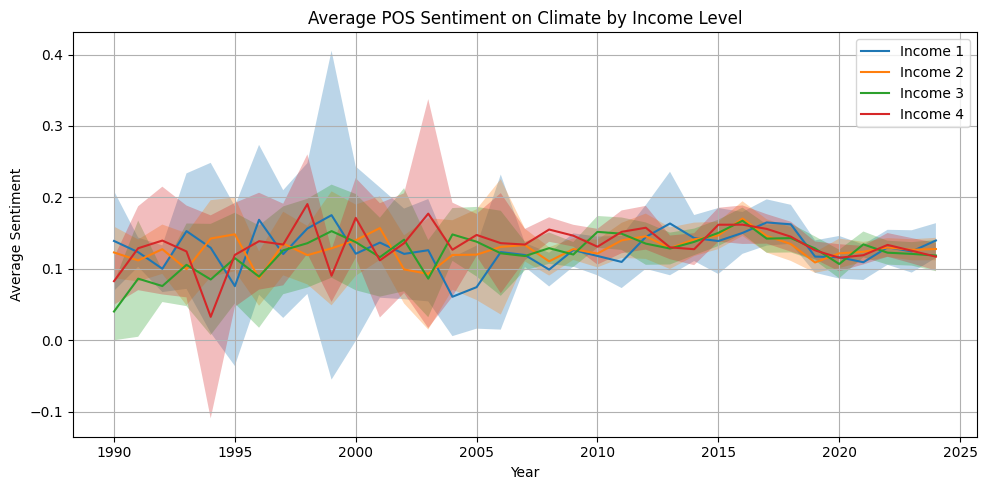

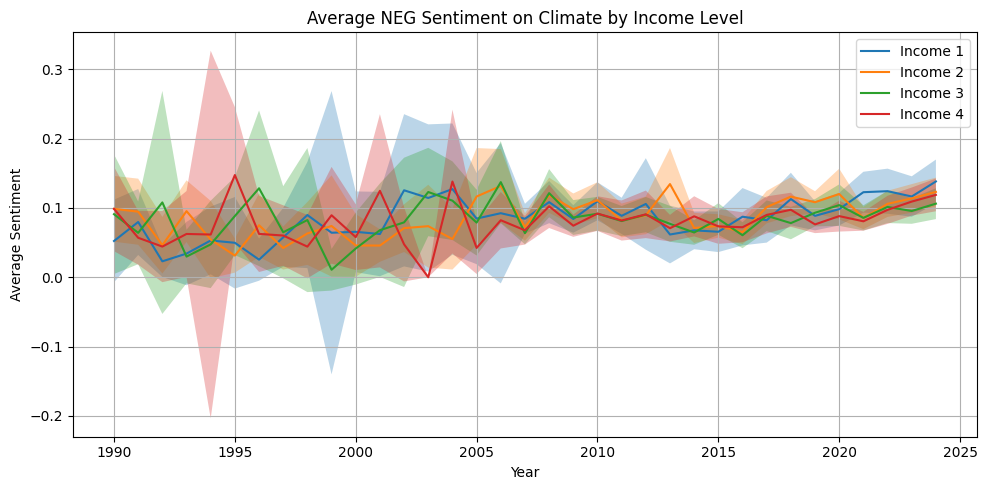

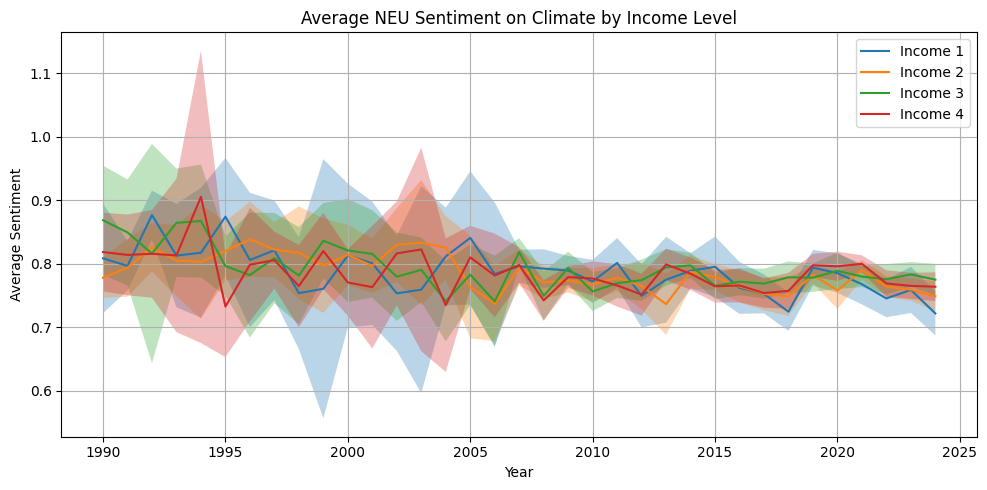

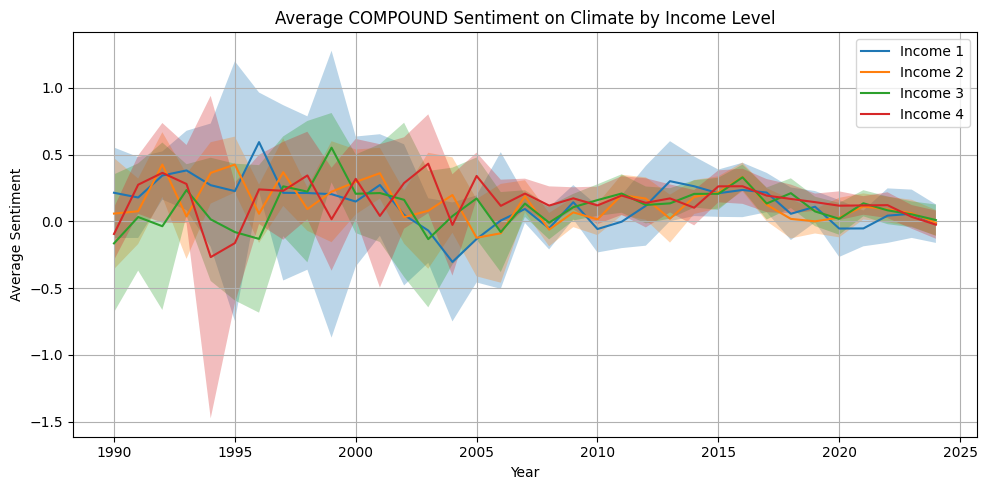

In [215]:
for sentiment in ['pos', 'neg', 'neu', 'compound']:
    plt.figure(figsize=(10, 5))
    for inc in range(1, 5):
        df_plot = all_income_df[inc]
        sns.lineplot(x='Year', y=f'mean_{sentiment}_{inc}', data=df_plot, label=f'Income {inc}')
        plt.fill_between(
            df_plot['Year'],
            df_plot[f'lower_{sentiment}_{inc}'],
            df_plot[f'upper_{sentiment}_{inc}'],
            alpha=0.3
        )
    plt.title(f'Average {sentiment.upper()} Sentiment on Climate by Income Level')
    plt.xlabel('Year')
    plt.ylabel('Average Sentiment')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path = Path(base_path) / "NLP_BDS" / f"avg_{sentiment.upper()}_by_income_level.png"
    plt.savefig(plot_path)

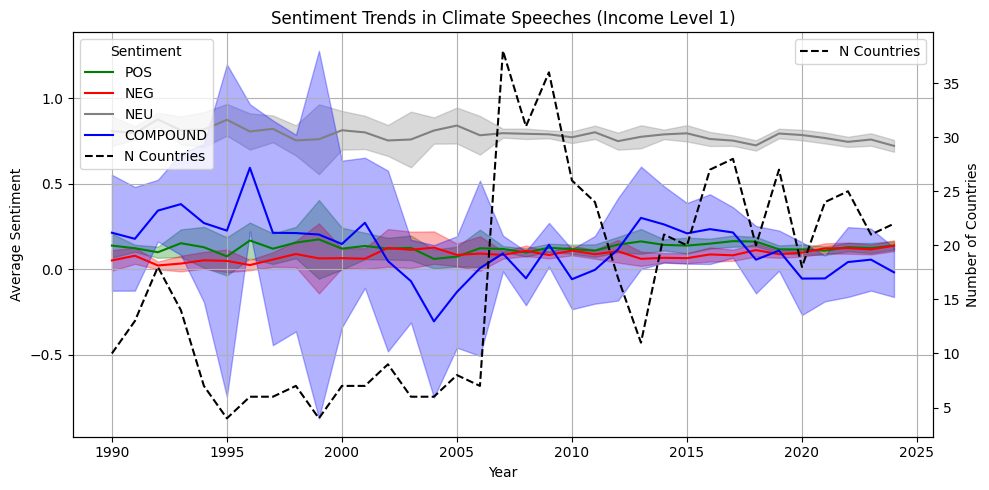

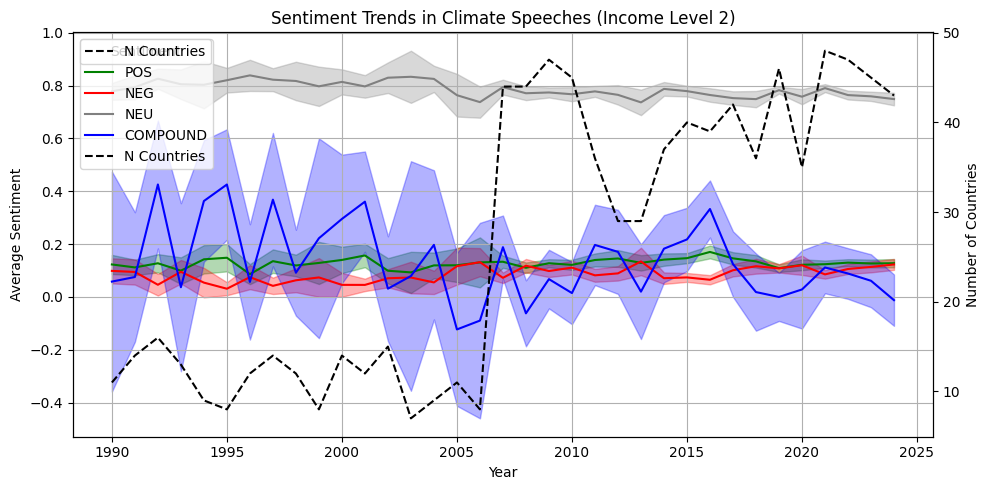

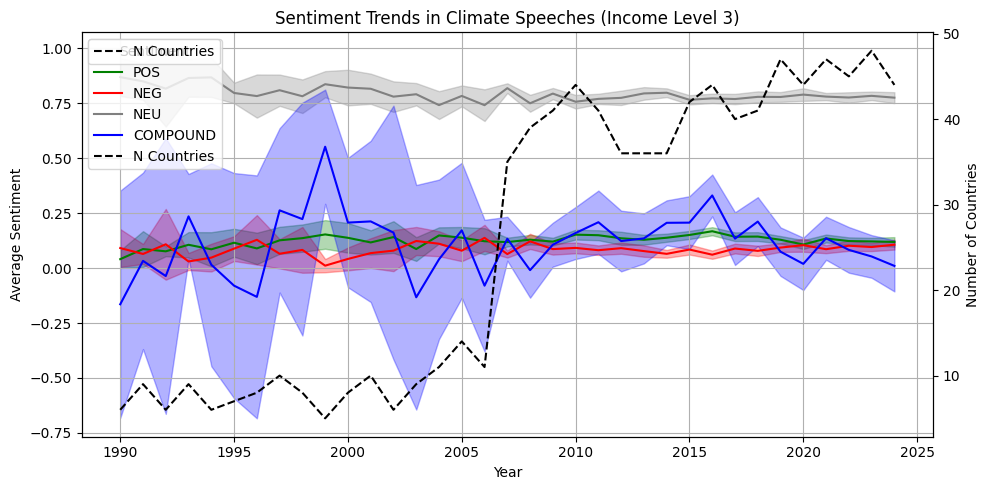

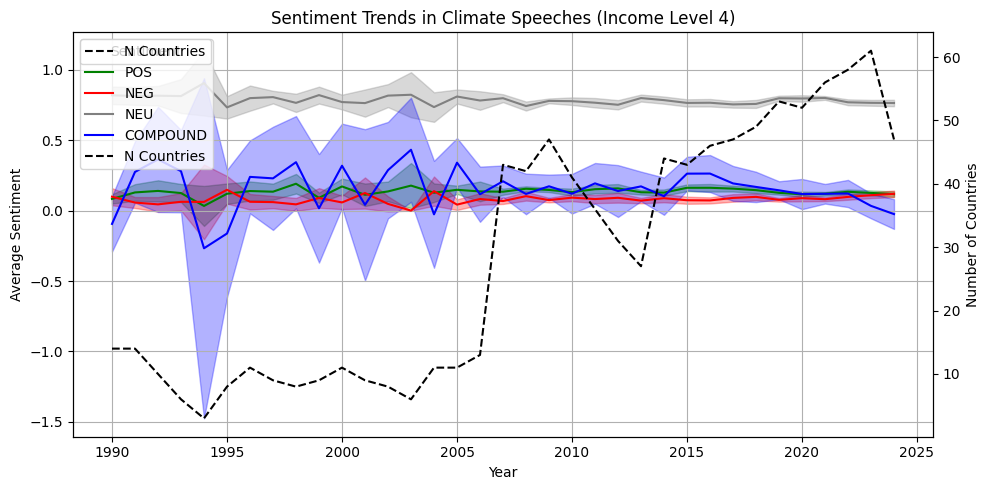

In [216]:
sentiments = ['pos', 'neg', 'neu', 'compound']
colors = {
    'pos': 'green',
    'neg': 'red',
    'neu': 'gray',
    'compound': 'blue'
}

for inc in range(1, 5):
    df_plot = all_income_df[inc]

    fig, ax1 = plt.subplots(figsize=(10, 5))  # ⬅️ create figure and main axis (sentiment)
    
    for s in sentiments:
        mean_col = f'mean_{s}_{inc}'
        lower_col = f'lower_{s}_{inc}'
        upper_col = f'upper_{s}_{inc}'

        sns.lineplot(
            x='Year', y=mean_col, data=df_plot, label=s.upper(), color=colors[s], ax=ax1
        )
        ax1.fill_between(
            df_plot['Year'],
            df_plot[lower_col],
            df_plot[upper_col],
            color=colors[s],
            alpha=0.3
        )

    # ➕ Secondary axis for number of countries
    ax2 = ax1.twinx()
    sns.lineplot(
        x='Year',
        y=f'n_countries_{inc}',
        data=df_plot,
        color='black',
        linestyle='--',
        linewidth=1.5,
        ax=ax2,
        label='N Countries'
    )
    ax2.set_ylabel('Number of Countries')

    # ✅ Titles, legends, save
    ax1.set_title(f'Sentiment Trends in Climate Speeches (Income Level {inc})')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Average Sentiment')
    ax1.grid(True)

    # Handle both legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', title='Sentiment')

    plt.tight_layout()
    plot_path = Path(base_path) / "NLP_BDS" / f"avg_sentiments_income_level_{inc}.png"
    plt.savefig(plot_path)
    #plt.show()


# EXTENDED SENTENCES

In [ ]:
def extract_climate_sentences_with_context(speech, keywords):
    """
    Extracts sentences containing climate keywords along with one sentence before and after each.
    Returns a list of context windows (strings of 1–3 sentences).
    """
    doc = list(nlp(speech).sents)  # Convert to list to access by index
    context_windows = []

    for i, sent in enumerate(doc):
        sent_text = sent.text.strip()

        if any(kw.lower() in sent_text.lower() for kw in keywords):
            # Grab the previous, current, and next sentence if available
            prev_sent = doc[i-1].text.strip() if i > 0 else ''
            next_sent = doc[i+1].text.strip() if i < len(doc) - 1 else ''
            
            context = ' '.join([s for s in [prev_sent, sent_text, next_sent] if s])
            context_windows.append(context)

    return context_windows


#df_sentiment_1 = df_sentiment.copy() 

#df_sentiment_1['climate_sentences_extended'] = df_sentiment_1.progress_apply(
#    lambda row: extract_climate_sentences_with_context(row['speeches_for_keyword_search'], row['matched_climate_keywords']),
#    axis=1
#)


100%|██████████| 3380/3380 [18:10<00:00,  3.10it/s]


In [ ]:
#df_sentiment_1.to_csv(base_path_alvaro / "Final_df_extended.csv", index=False, encoding='utf-8')

## SENTIMENT ANALYSIS

In [22]:
final_df = pd.read_csv(base_path / "Final_df_extended.csv")
df_sentiment = final_df[final_df['contains_climate_keyword'] != False]
df_sentiment

,Session,Year,ISO-Code,Speech,number_sentences,number_tokens,Income Level,cleaned_speeches_postagging_expanded,speeches_for_keyword_search,matched_climate_keywords,contains_climate_keyword,climate_sentences,climate_sentences_extended
0,45,1990,ATG,"﻿Please accept my country's congratulations, S...",115,3134,3,please accept country congratulation sir unani...,please accept my country's congratulations sir...,['global warming'],True,['our oceans are polluted by various contamina...,"[""rain forests the most valuable of mankind's ..."
1,45,1990,AUS,"﻿It is with great pleasure. Sir, that I congra...",162,5289,4,great pleasure sir congratulate election presi...,it is with great pleasure. sir that i congratu...,['global environment'],True,['in areas such as threats to the global envir...,['in addition to the abiding issues of securit...
2,45,1990,AUT,"﻿\n\nI am pleased, Sir, to congratulate you on...",162,4743,4,pleased sir congratulate election presidency g...,i am pleased sir to congratulate you on your e...,"['carbon dioxide', 'emissions', 'global enviro...",True,['one of the most urgent priority measures one...,['studies undertaken at the vienna-based inter...
3,45,1990,BFA,"﻿\nMr. President, events in Eastern and Centra...",91,2948,1,president event eastern central europe gratify...,mr. president events in eastern and central eu...,"['carbon dioxide', 'greenhouse effect', 'ozone...",True,['we must urgently orient research towards tec...,['the same applies to the survival of our plan...
4,45,1990,BGD,"﻿\nMr. President, warm felicitations are due y...",180,3107,1,president warm felicitation due welldeserved e...,mr. president warm felicitations are due you o...,['climate change'],True,['we hope the proposed conventions on climate ...,['the conference must produce results that wil...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3375,79,2024,WSM,"Excellencies, \nI extend my congratulations t...",68,1572,2,excellency extend congratulation excellency ph...,excellencies i extend my congratulations to hi...,"['climate change', 'climate action', 'temperat...",True,['the effects of climate change are being live...,['please be assured of samoas support in the s...
3376,79,2024,YEM,"Your Majesties, Excellencies, and Highnesses, ...",57,1876,1,lady gentleman happy coincidence address today...,ladies and gentlemen it is a happy coincidence...,['climate change'],True,['this includes not only immediate humanitaria...,['for this reason the republic of yemen renews...
3377,79,2024,ZAF,President of the 79th Session of the UN Genera...,100,1870,3,president session general assembly philemon ya...,president of the 79th session of the un genera...,"['climate change', 'climate action', 'emission...",True,['as signatory to the paris agreement we are c...,['a few days ago south africa also endorsed th...
3378,79,2024,ZMB,"\n YOUR EXCELLENCY PHILEMON YANG, PRESIDENT O...",81,2348,2,lady gentleman congratulate excellency assumpt...,ladies and gentlemen i congratulate you your e...,"['climate change', 'extreme weather', 'climate...",True,['mr. president climate change and extreme wea...,"[""furthermore zambia recognises the efforts of..."


In [23]:
type(df_sentiment.iloc[0]['climate_sentences_extended'])

str

In [24]:
type(df_sentiment.iloc[0]['matched_climate_keywords'])

str

In [25]:
df_sentiment = clean_and_lowercase_list_column(df_sentiment, 'matched_climate_keywords')
type(df_sentiment.iloc[0]['matched_climate_keywords'])

list

In [26]:
df_sentiment = clean_and_lowercase_list_column(df_sentiment, 'climate_sentences_extended')
type(df_sentiment.iloc[0]['climate_sentences_extended'])

list

In [222]:
all_income_df = get_ci_and_average(df_sentiment, 'climate_sentences_extended')

1
 ------------------------------Income 1 ------------------------------
578
2
 ------------------------------Income 2 ------------------------------
925
3
 ------------------------------Income 3 ------------------------------
893
4
 ------------------------------Income 4 ------------------------------
984


In [223]:
all_income_df[4]

,Year,n_countries_4,mean_neg_4,lower_neg_4,upper_neg_4,mean_neu_4,lower_neu_4,upper_neu_4,mean_pos_4,lower_pos_4,upper_pos_4,mean_compound_4,lower_compound_4,upper_compound_4
0,1990,14,0.082974,0.059870,0.106079,0.800304,0.769756,0.830852,0.116799,0.096743,0.136856,0.195161,-0.061625,0.451948
1,1991,14,0.038105,0.015414,0.060795,0.801888,0.763983,0.839793,0.160055,0.126914,0.193196,0.653904,0.486010,0.821797
2,1992,10,0.060000,0.006894,0.113106,0.800300,0.750577,0.850023,0.139600,0.091638,0.187562,0.429260,-0.088548,0.947068
3,1993,6,0.063889,0.003051,0.124727,0.819417,0.761954,0.876880,0.116694,0.095146,0.138243,0.349300,-0.188312,0.886912
4,1994,3,0.083000,0.034068,0.131932,0.856333,0.743303,0.969364,0.061333,-0.005616,0.128282,-0.451567,-0.667627,-0.235507
5,1995,8,0.084542,0.020374,0.148710,0.758000,0.689362,0.826638,0.157625,0.106439,0.208811,0.362258,-0.146528,0.871045
6,1996,11,0.030682,0.011239,0.050125,0.788955,0.749495,0.828414,0.180364,0.134633,0.226094,0.704380,0.535827,0.872932
7,1997,9,0.051852,0.019565,0.084139,0.804009,0.742328,0.865691,0.144083,0.088118,0.200049,0.426061,0.063761,0.788361
8,1998,8,0.032438,-0.005461,0.070336,0.797175,0.730866,0.863484,0.170563,0.119317,0.221808,0.682820,0.508761,0.856879
9,1999,9,0.090435,0.027937,0.152933,0.769296,0.714410,0.824182,0.140102,0.104512,0.175692,0.301505,-0.228000,0.831009


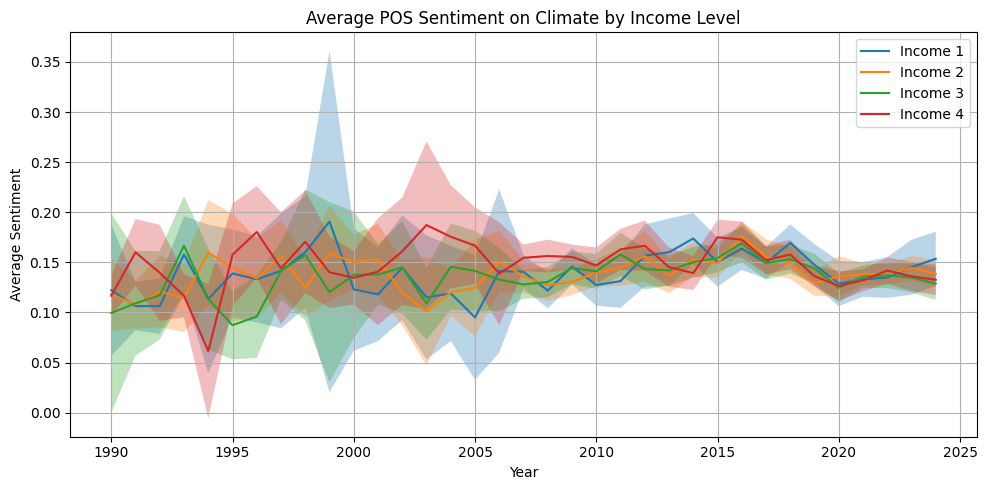

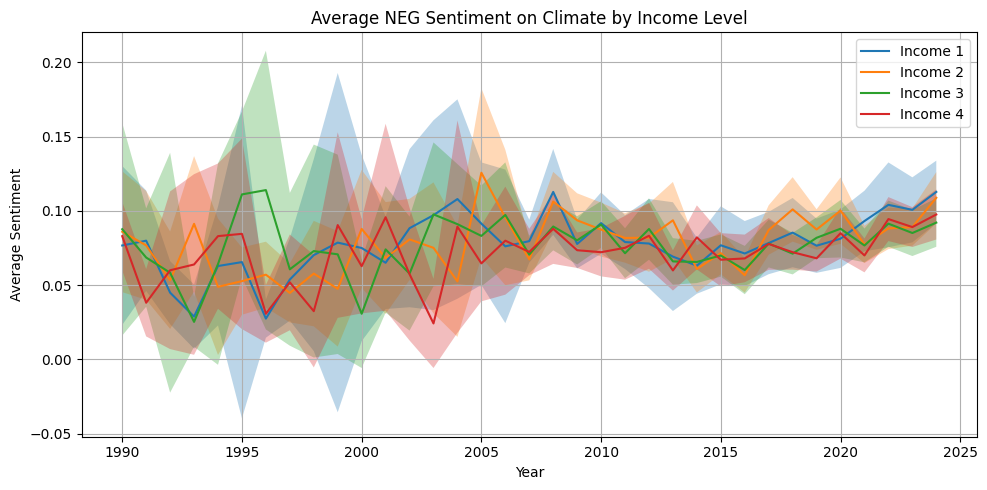

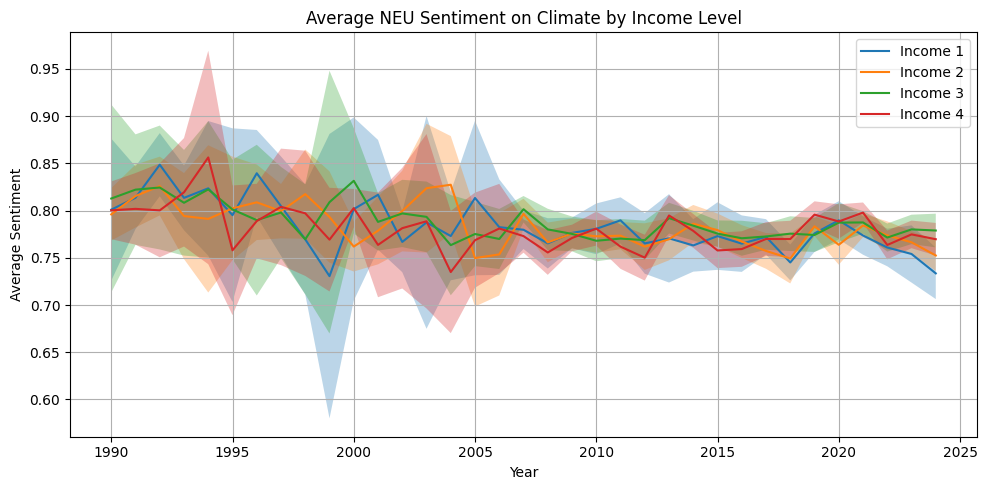

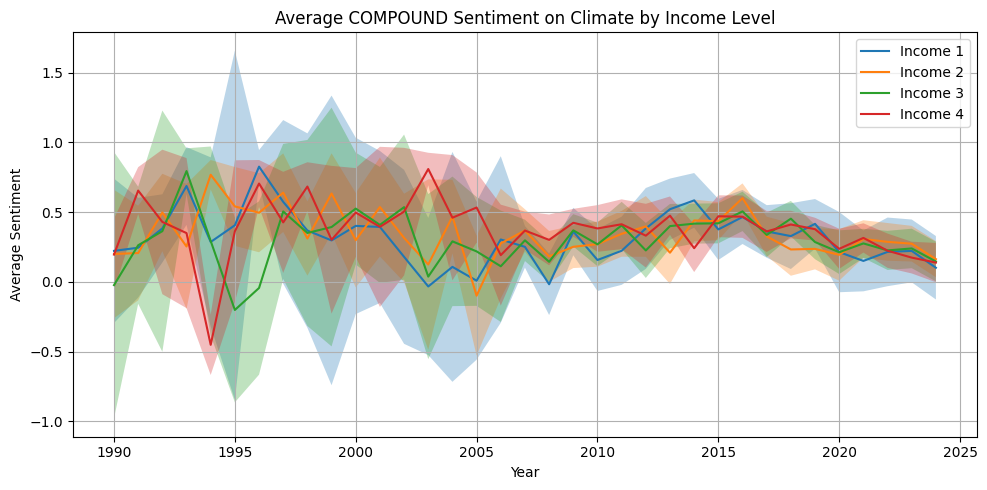

In [224]:
for sentiment in ['pos', 'neg', 'neu', 'compound']:
    plt.figure(figsize=(10, 5))
    for inc in range(1, 5):
        df_plot = all_income_df[inc]
        sns.lineplot(x='Year', y=f'mean_{sentiment}_{inc}', data=df_plot, label=f'Income {inc}')
        plt.fill_between(
            df_plot['Year'],
            df_plot[f'lower_{sentiment}_{inc}'],
            df_plot[f'upper_{sentiment}_{inc}'],
            alpha=0.3
        )
    plt.title(f'Average {sentiment.upper()} Sentiment on Climate by Income Level')
    plt.xlabel('Year')
    plt.ylabel('Average Sentiment')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path = Path(base_path) / "NLP_BDS" / f"avg_{sentiment.upper()}_by_income_level_EXTENDED_SENTENCES.png"
    plt.savefig(plot_path)

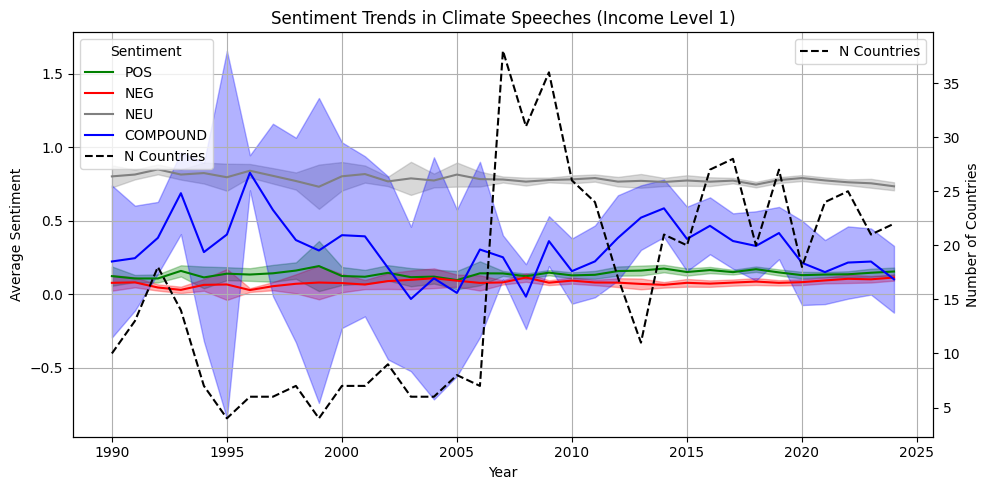

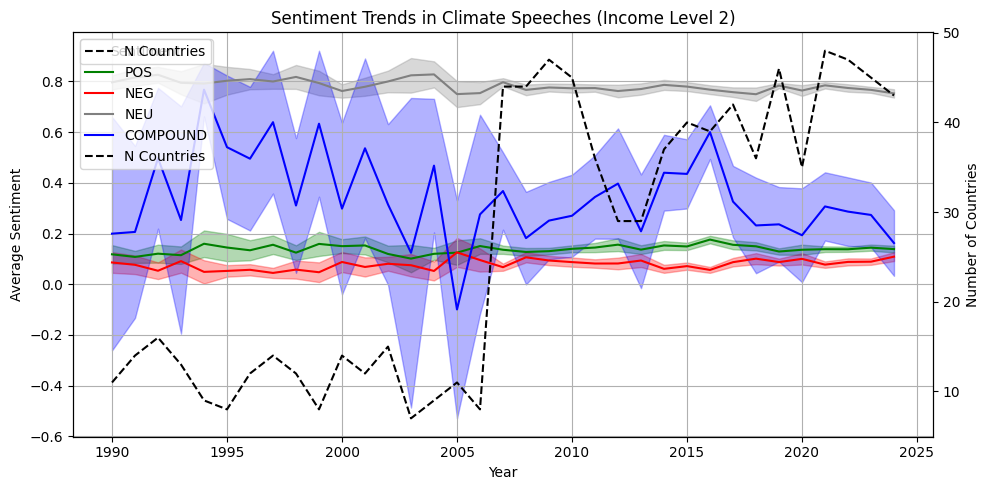

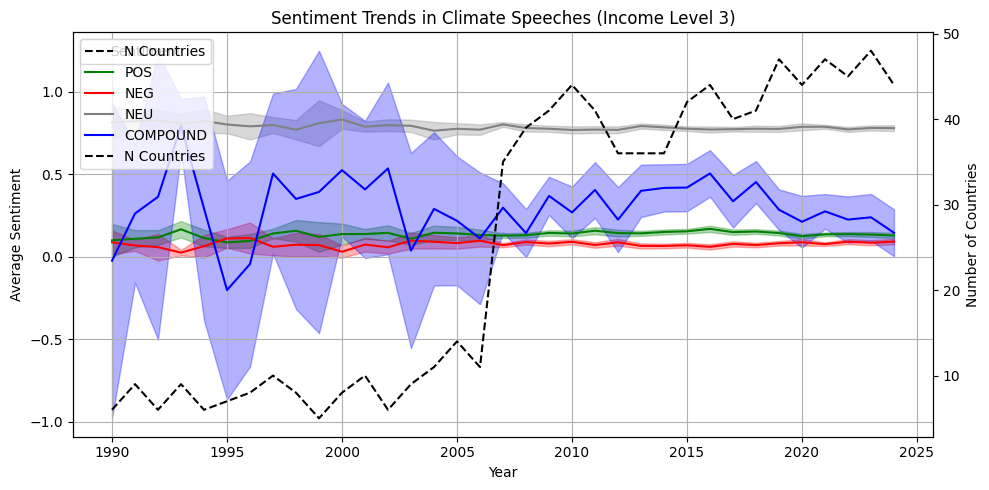

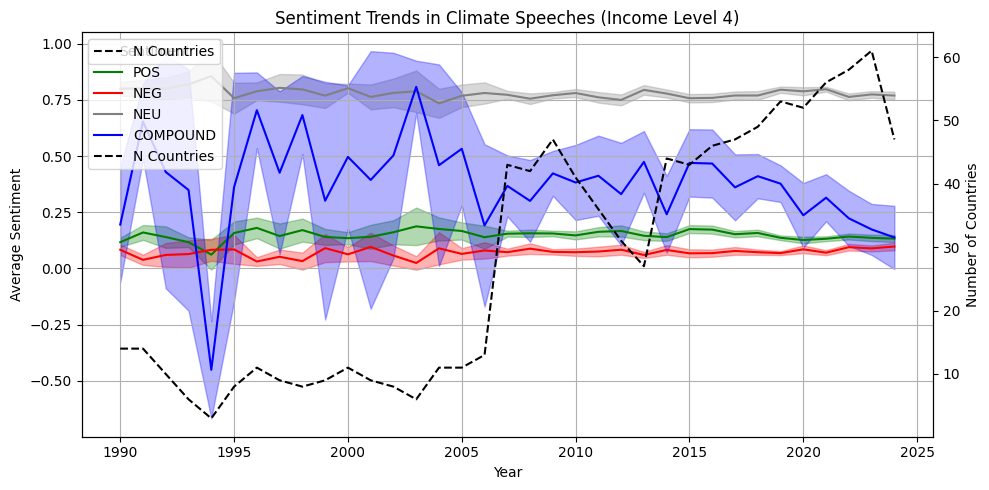

In [225]:
sentiments = ['pos', 'neg', 'neu', 'compound']
colors = {
    'pos': 'green',
    'neg': 'red',
    'neu': 'gray',
    'compound': 'blue'
}

for inc in range(1, 5):
    df_plot = all_income_df[inc]

    fig, ax1 = plt.subplots(figsize=(10, 5))  # ⬅️ create figure and main axis (sentiment)
    
    for s in sentiments:
        mean_col = f'mean_{s}_{inc}'
        lower_col = f'lower_{s}_{inc}'
        upper_col = f'upper_{s}_{inc}'

        sns.lineplot(
            x='Year', y=mean_col, data=df_plot, label=s.upper(), color=colors[s], ax=ax1
        )
        ax1.fill_between(
            df_plot['Year'],
            df_plot[lower_col],
            df_plot[upper_col],
            color=colors[s],
            alpha=0.3
        )

    # ➕ Secondary axis for number of countries
    ax2 = ax1.twinx()
    sns.lineplot(
        x='Year',
        y=f'n_countries_{inc}',
        data=df_plot,
        color='black',
        linestyle='--',
        linewidth=1.5,
        ax=ax2,
        label='N Countries'
    )
    ax2.set_ylabel('Number of Countries')

    # ✅ Titles, legends, save
    ax1.set_title(f'Sentiment Trends in Climate Speeches (Income Level {inc})')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Average Sentiment')
    ax1.grid(True)

    # Handle both legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', title='Sentiment')

    plt.tight_layout()
    plot_path = Path(base_path) / "NLP_BDS" / f"avg_sentiments_income_level_{inc}_EXTENDED_SENTENCES.png"
    plt.savefig(plot_path)
    #plt.show()


# Count the number of Positive and Negative Sentences per income group

In [29]:
import urllib.request

url = "https://gist.githubusercontent.com/bastings/d6f99dcb6c82231b94b013031356ba05/raw/f80a0281eba8621b122012c89c8b5e2200b39fd6/sent_lexicon"
output_file = "sent_lexicon"

urllib.request.urlretrieve(url, output_file)
print("Downloaded successfully.")


Downloaded successfully.


In [45]:
lexicon_dict = {}

with open("sent_lexicon", mode="r", encoding="utf-8") as f:
    for line in f:
        pairs = line.split()
        word = pairs[2].split('=')[1]
        pol = pairs[-1].split('=')[1]
        subtype = pairs[0].split('=')[1]

        # Convert string polarity to numeric value
        if pol == "positive":
            polarity = 1
        elif pol == "neutral":
            polarity = 0
        elif pol == "negative":
            polarity = -1
        else:
            polarity = 0  # fallback in case of unexpected value

        # Strengthen polarity if it's a strong subjectivity word
        if subtype == 'strongsubj':
            polarity *= 2

        lexicon_dict[word] = polarity

# Optional: check a few entries
print({k: lexicon_dict[k] for k in list(lexicon_dict)[:10]})


{'abandoned': -1, 'abandonment': -1, 'abandon': -1, 'abase': -2, 'abasement': -2, 'abash': -2, 'abate': -1, 'abdicate': -1, 'aberration': -2, 'abhor': -2}


In [110]:
df = df_sentiment[['climate_sentences_extended', 'Income Level']]

# Function to remove punctuation from a sentence
def clean_sent_list(sent_list):
    return [re.sub(r'[^\w\s]', '', sent) for sent in sent_list]

# Apply to your DataFrame column
df['climate_sentences_extended_no_punctuation'] = df['climate_sentences_extended'].apply(clean_sent_list)
df

C:\Users\alvar\AppData\Local\Temp\ipykernel_2316\1892929227.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['climate_sentences_extended_no_punctuation'] = df['climate_sentences_extended'].apply(clean_sent_list)


,climate_sentences_extended,Income Level,climate_sentences_extended_no_punctuation
0,[rain forests the most valuable of mankind's t...,3,[rain forests the most valuable of mankinds te...
1,[in addition to the abiding issues of security...,4,[in addition to the abiding issues of security...
2,[studies undertaken at the vienna-based intern...,4,[studies undertaken at the viennabased interna...
3,[the same applies to the survival of our plane...,1,[the same applies to the survival of our plane...
4,[the conference must produce results that will...,1,[the conference must produce results that will...
...,...,...,...
3375,[please be assured of samoas support in the su...,2,[please be assured of samoas support in the su...
3376,[for this reason the republic of yemen renews ...,1,[for this reason the republic of yemen renews ...
3377,[a few days ago south africa also endorsed the...,3,[a few days ago south africa also endorsed the...
3378,[furthermore zambia recognises the efforts of ...,2,[furthermore zambia recognises the efforts of ...


In [117]:
for i in range(1, 5):
    print('---------------------------- Income Level', i, "-------------------------------")
    groupped_df = df[df['Income Level'] == i]

    print("In this group there is a total of", len(groupped_df), "entries")

    positive = 0
    negative = 0
    neutral = 0
    base_threshold = 2

    for row_idx in range(len(groupped_df)):
        for sentence in groupped_df.iloc[row_idx]['climate_sentences_extended_no_punctuation']:
            tokens = sentence.split()
            token_scores = [lexicon_dict.get(token, 0) for token in tokens]
            score = sum(token_scores)

            if score > base_threshold:
                positive += 1
            elif score == base_threshold:
                neutral += 1
            else:
                negative += 1

    total = positive + negative + neutral
    print(f"There is a total of {positive} positive sentences out of {total}")
    print(f"There is a total of {negative} negative sentences out of {total}")
    print(f"There is a total of {neutral} neutral sentences out of {total}")


---------------------------- Income Level 1 -------------------------------
In this group there is a total of 578 entries
There is a total of 969 positive sentences out of 1870
There is a total of 767 negative sentences out of 1870
There is a total of 134 neutral sentences out of 1870
---------------------------- Income Level 2 -------------------------------
In this group there is a total of 925 entries
There is a total of 2302 positive sentences out of 4348
There is a total of 1706 negative sentences out of 4348
There is a total of 340 neutral sentences out of 4348
---------------------------- Income Level 3 -------------------------------
In this group there is a total of 893 entries
There is a total of 2255 positive sentences out of 4196
There is a total of 1599 negative sentences out of 4196
There is a total of 342 neutral sentences out of 4196
---------------------------- Income Level 4 -------------------------------
In this group there is a total of 984 entries
There is a total

## Watch out for them long sentences

In [116]:
for i in range(1, 5):
    print('---------------------------- Income Level', i, "-------------------------------")
    groupped_df = df[df['Income Level'] == i]

    print("In this group there is a total of", len(groupped_df), "entries")

    positive = 0
    negative = 0
    neutral = 0
    base_threshold = 2

    for row_idx in range(len(groupped_df)):
        for sentence in groupped_df.iloc[row_idx]['climate_sentences_extended_no_punctuation']:
            tokens = sentence.split()
            token_scores = [lexicon_dict.get(token, 0) for token in tokens]
            score = sum(token_scores)

            # Use scaled threshold based on sentence length
            threshold = base_threshold * len(tokens)

            if score > threshold:
                positive += 1
            elif score == threshold:
                neutral += 1
            else:
                negative += 1

    total = positive + negative + neutral
    print(f"There is a total of {positive} positive sentences out of {total}")
    print(f"There is a total of {negative} negative sentences out of {total}")
    print(f"There is a total of {neutral} neutral sentences out of {total}")


---------------------------- Income Level 1 -------------------------------
In this group there is a total of 578 entries
There is a total of 0 positive sentences out of 1870
There is a total of 1870 negative sentences out of 1870
There is a total of 0 neutral sentences out of 1870
---------------------------- Income Level 2 -------------------------------
In this group there is a total of 925 entries
There is a total of 0 positive sentences out of 4348
There is a total of 4348 negative sentences out of 4348
There is a total of 0 neutral sentences out of 4348
---------------------------- Income Level 3 -------------------------------
In this group there is a total of 893 entries
There is a total of 0 positive sentences out of 4196
There is a total of 4196 negative sentences out of 4196
There is a total of 0 neutral sentences out of 4196
---------------------------- Income Level 4 -------------------------------
In this group there is a total of 984 entries
There is a total of 0 positiv